In [75]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np

device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

cuda


In [76]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root = "C:/Users/my Hsieh/Desktop/Deep Learning/PJ2_2026/codes", train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root = "C:/Users/my Hsieh/Desktop/Deep Learning/PJ2_2026/codes", train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Your network will have all the following components:(16%)
- (a) Fully-Connected layer;
- (b) 2D convolutional layer;
- (c) 2D pooling layer;
- (d) Activations;

Your network may have some of (at least one) the following components:(8%)
- (a) Batch-Norm layer;
- (b) Drop out;
- (c) Residual Connection;
- (d) Others;

采用的网络结构为：输入->卷积->批归一化->最大池化（降采样）->残差连接->卷积（降采样）->批归一化->残差连接->dropout->全连接

In [77]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, act_fn):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.act = act_fn()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + x)  


class CNNskeleton(nn.Module):
    def __init__(self, out_dim=32, act_fn=nn.ReLU):
        super().__init__()
        self.act = act_fn()

        self.conv1 = nn.Conv2d(3, out_dim, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_dim)
        self.pool = nn.MaxPool2d(2, 2)
        self.res_block1 = ResidualBlock(out_dim, act_fn)
        
        self.conv2 = nn.Conv2d(out_dim, out_dim * 2, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_dim * 2)
        self.res_block2 = ResidualBlock(out_dim * 2, act_fn)
        
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(out_dim * 2 * 8 * 8, 10)

    def forward(self, x):
        # 阶段 1
        x = self.pool(self.act(self.bn1(self.conv1(x))))
        x = self.res_block1(x)
        
        # 阶段 2
        x = self.act(self.bn2(self.conv2(x)))
        x = self.res_block2(x)
        
        x = self.dropout(x)
        
        # 展平输入到全连接层
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [78]:
def run_epoch(model, dataloader, criterion, optimizer, device, is_train=True):
    if is_train:
        model.train()
        torch.set_grad_enabled(True)
    else:
        model.eval()
        torch.set_grad_enabled(False)

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        if is_train:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100.0 * correct / total

In [79]:
def run_experiment(
    out_dim=32,                     # (4.a) 通道数 / 神经元数
    act_fn=nn.ReLU,                  # (4.c) 激活函数类型
    loss_fn=nn.CrossEntropyLoss,     # (4.b) 损失函数类型
    weight_decay=1e-4,               # (4.b) L2正则化强度
    optimizer_type='sgd',           # (5.a) 优化器类型：'adam' 或 'sgd'
    lr=0.001,
    epochs=20,
    save_prefix='baseline'
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"==================================================")
    print(f" experiment: {save_prefix}")
    print(f" out_dim={out_dim} | act_fn= {act_fn.__name__} | loss_fn={loss_fn.__name__} \n"
          f" optimizer_type={optimizer_type} | weight_decay= {weight_decay}")
    print(f"==================================================")

    model = CNNskeleton(out_dim=out_dim, act_fn=act_fn).to(device)
    criterion = loss_fn()

    if optimizer_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError("Unsupported optimizer")

    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
    best_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(model, trainloader, criterion, optimizer, device, is_train=True)
        _, test_acc = run_epoch(model, testloader, criterion, optimizer, device, is_train=False)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        print(f"Epoch [{epoch+1:02d}/{epochs:02d}] | "
              f"Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Test Acc: {test_acc:.2f}%")
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), f'{save_prefix}_best_model.pth')

    torch.save(history, f'{save_prefix}_train_history.pt')
    return history

In [80]:
def visualize_filters(save_prefix='baseline', out_dim=32, act_fn=nn.ReLU):
    model = CNNskeleton(out_dim=out_dim, act_fn=act_fn)
    model_path = f'{save_prefix}_best_model.pth'
    #normalize weights of fliters
    filters = model.conv1.weight.data.numpy()
    filters_min, filters_max = filters.min(), filters.max()
    filters = (filters - filters_min) / (filters_max - filters_min)
    
    num_filters = filters.shape[0]
    n_cols = 8
    n_rows = (num_filters + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 1.25))
    fig.suptitle(f"Conv1 Filters Visualization ({save_prefix})", fontsize=14)
    
    for i, ax in enumerate(axes.flat):
        if i < num_filters:
            # 转置通道顺序：(in_channels, H, W) -> (H, W, in_channels)
            img = np.transpose(filters[i], (1, 2, 0))
            ax.imshow(img)
            ax.set_title(f"F {i+1}", fontsize=8)
        ax.axis('off')
        
    plt.tight_layout()

    plt.savefig(f'{save_prefix}_filters.png', dpi=300)
    plt.show()

In [81]:
def plot_comparison_curves(experiments_dict, save_name="comparison_curves.png"):
    data = {label: torch.load(f'{prefix}_train_history.pt') for prefix, label in experiments_dict.items()}
    
    plt.figure(figsize=(14, 5))
    
    # 1. 绘制 Loss 对比
    plt.subplot(1, 2, 1)
    for label, history in data.items():
        epochs = range(1, len(history['train_loss']) + 1)
        plt.plot(epochs, history['train_loss'], '-', label=label)
    plt.title('Training Loss Comparison', fontsize=12)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    # 2. 绘制 Accuracy 对比 
    plt.subplot(1, 2, 2)
    for label, history in data.items():
        epochs = range(1, len(history['test_acc']) + 1)
        p = plt.plot(epochs, history['train_acc'], '-', label=f"{label} (Train)")
        plt.plot(epochs, history['test_acc'], '--', color=p[0].get_color(), label=f"{label} (Test)")
        
    plt.title('Accuracy Comparison', fontsize=12)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=300)
    plt.show()

In [82]:
def CNN(var_name, var_values, **kwargs):
    experiments_dict = {}
    
    for val in var_values:
        label = val.__name__ if hasattr(val, '__name__') else str(val)
        save_prefix = f"CNN_{var_name}_{label}"
        
        params = kwargs.copy()
        params[var_name] = val
        params['save_prefix'] = save_prefix
        
        run_experiment(**params)
        
        experiments_dict[save_prefix] = f"{var_name}={label}"
        
    plot_comparison_curves(experiments_dict, save_name=f"CNN_{var_name}_comparison.png")

4. To optimize your network, you will try all the following strategies:(8%)
- (a) Try different number of neurons/filters;

 experiment: CNN_out_dim_16
 out_dim=16 | act_fn= ReLU | loss_fn=CrossEntropyLoss 
 optimizer_type=sgd | weight_decay= 0.0001
Epoch [01/20] | Loss: 1.4431 | Train Acc: 48.42% | Test Acc: 59.51%
Epoch [02/20] | Loss: 1.0947 | Train Acc: 61.12% | Test Acc: 64.43%
Epoch [03/20] | Loss: 0.9436 | Train Acc: 66.68% | Test Acc: 67.89%
Epoch [04/20] | Loss: 0.8655 | Train Acc: 69.55% | Test Acc: 69.50%
Epoch [05/20] | Loss: 0.7935 | Train Acc: 72.11% | Test Acc: 71.24%
Epoch [06/20] | Loss: 0.7512 | Train Acc: 73.84% | Test Acc: 72.27%
Epoch [07/20] | Loss: 0.7184 | Train Acc: 74.97% | Test Acc: 73.92%
Epoch [08/20] | Loss: 0.6853 | Train Acc: 76.13% | Test Acc: 74.42%
Epoch [09/20] | Loss: 0.6611 | Train Acc: 76.88% | Test Acc: 74.58%
Epoch [10/20] | Loss: 0.6365 | Train Acc: 77.65% | Test Acc: 73.56%
Epoch [11/20] | Loss: 0.6132 | Train Acc: 78.67% | Test Acc: 74.82%
Epoch [12/20] | Loss: 0.5983 | Train Acc: 79.11% | Test Acc: 75.24%
Epoch [13/20] | Loss: 0.5797 | Train Acc: 79.71% | Test Ac

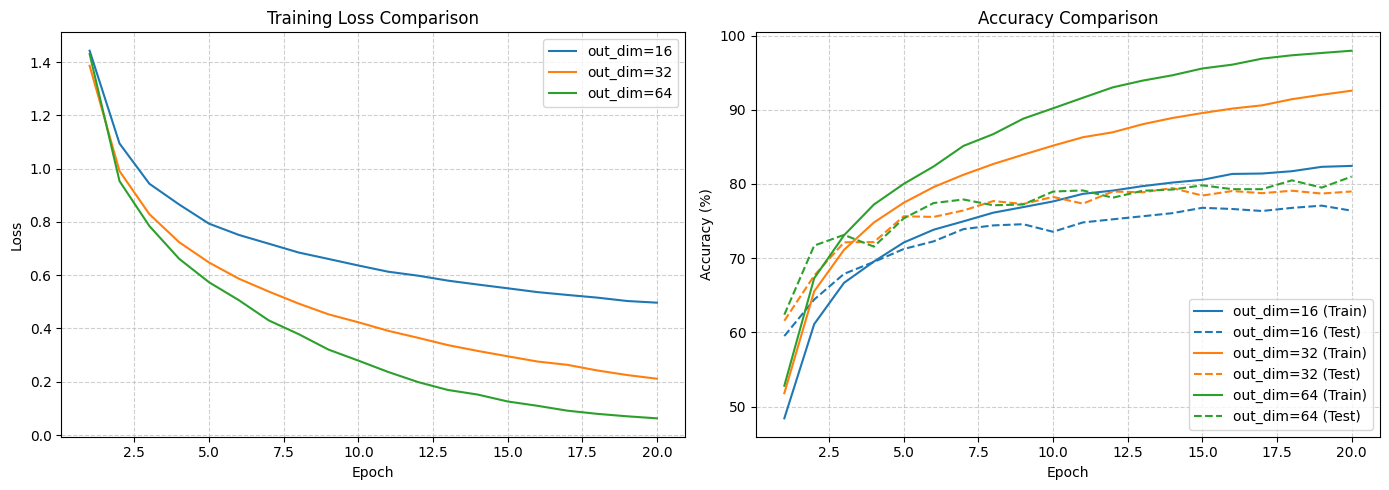

In [83]:
CNN(
    var_name='out_dim', 
    var_values=[16, 32, 64], 
    act_fn=nn.ReLU, 
    weight_decay=1e-4,
    optimizer_type='sgd', 
    lr=0.001, 
    epochs=20
)

(b) Try different loss functions (with different regularization);

 experiment: CNN_weight_decay_0.0001
 out_dim=32 | act_fn= ReLU | loss_fn=CrossEntropyLoss 
 optimizer_type=sgd | weight_decay= 0.0001
Epoch [01/20] | Loss: 1.3853 | Train Acc: 51.88% | Test Acc: 64.33%
Epoch [02/20] | Loss: 0.9717 | Train Acc: 66.21% | Test Acc: 68.15%
Epoch [03/20] | Loss: 0.8134 | Train Acc: 71.64% | Test Acc: 71.95%
Epoch [04/20] | Loss: 0.7133 | Train Acc: 75.01% | Test Acc: 72.31%
Epoch [05/20] | Loss: 0.6390 | Train Acc: 77.65% | Test Acc: 75.03%
Epoch [06/20] | Loss: 0.5793 | Train Acc: 79.77% | Test Acc: 74.91%
Epoch [07/20] | Loss: 0.5332 | Train Acc: 81.42% | Test Acc: 76.25%
Epoch [08/20] | Loss: 0.4889 | Train Acc: 82.97% | Test Acc: 77.12%
Epoch [09/20] | Loss: 0.4518 | Train Acc: 84.03% | Test Acc: 76.61%
Epoch [10/20] | Loss: 0.4193 | Train Acc: 85.24% | Test Acc: 77.24%
Epoch [11/20] | Loss: 0.3872 | Train Acc: 86.34% | Test Acc: 76.83%
Epoch [12/20] | Loss: 0.3634 | Train Acc: 87.19% | Test Acc: 76.56%
Epoch [13/20] | Loss: 0.3383 | Train Acc: 87.99% 

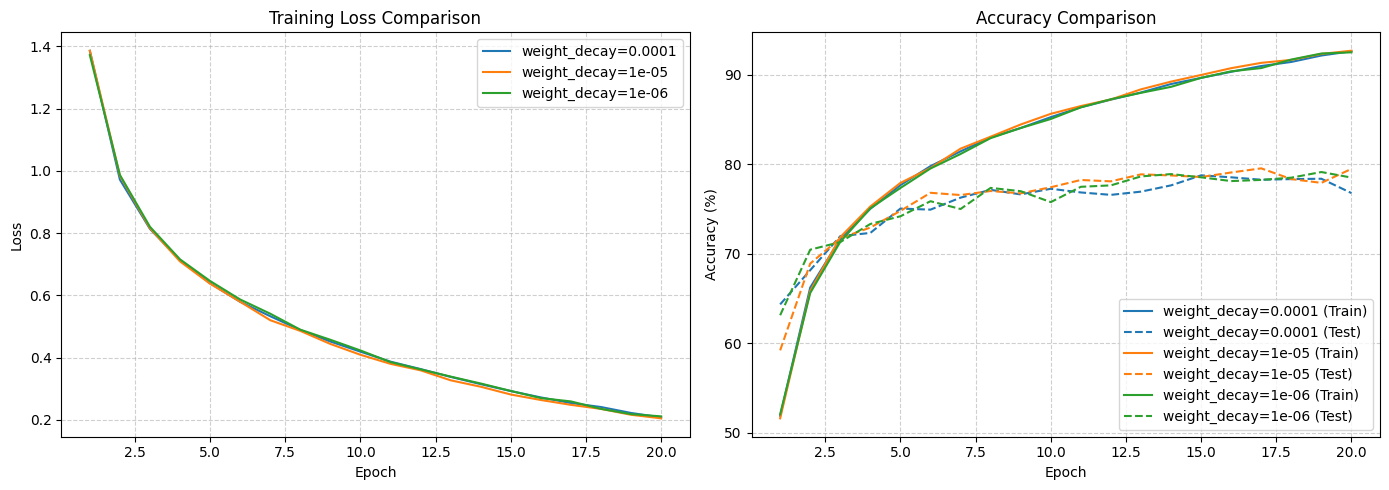

In [84]:
CNN(
    var_name='weight_decay',
    var_values=[1e-4, 1e-5, 1e-6],
    out_dim=32, 
    act_fn=nn.ReLU, 
    optimizer_type='sgd', 
    lr=0.001, 
    epochs=20
)

(c) Try different activations;

 experiment: CNN_act_fn_ReLU
 out_dim=32 | act_fn= ReLU | loss_fn=CrossEntropyLoss 
 optimizer_type=sgd | weight_decay= 0.0001
Epoch [01/20] | Loss: 1.3839 | Train Acc: 52.02% | Test Acc: 62.88%
Epoch [02/20] | Loss: 0.9893 | Train Acc: 65.60% | Test Acc: 69.25%
Epoch [03/20] | Loss: 0.8246 | Train Acc: 71.27% | Test Acc: 69.65%
Epoch [04/20] | Loss: 0.7199 | Train Acc: 74.68% | Test Acc: 74.83%
Epoch [05/20] | Loss: 0.6460 | Train Acc: 77.34% | Test Acc: 76.03%
Epoch [06/20] | Loss: 0.5858 | Train Acc: 79.61% | Test Acc: 77.19%
Epoch [07/20] | Loss: 0.5376 | Train Acc: 81.15% | Test Acc: 75.46%
Epoch [08/20] | Loss: 0.4900 | Train Acc: 82.86% | Test Acc: 76.16%
Epoch [09/20] | Loss: 0.4543 | Train Acc: 84.17% | Test Acc: 78.59%
Epoch [10/20] | Loss: 0.4182 | Train Acc: 85.29% | Test Acc: 77.49%
Epoch [11/20] | Loss: 0.3965 | Train Acc: 86.10% | Test Acc: 78.18%
Epoch [12/20] | Loss: 0.3624 | Train Acc: 87.26% | Test Acc: 78.10%
Epoch [13/20] | Loss: 0.3395 | Train Acc: 87.98% | Test A

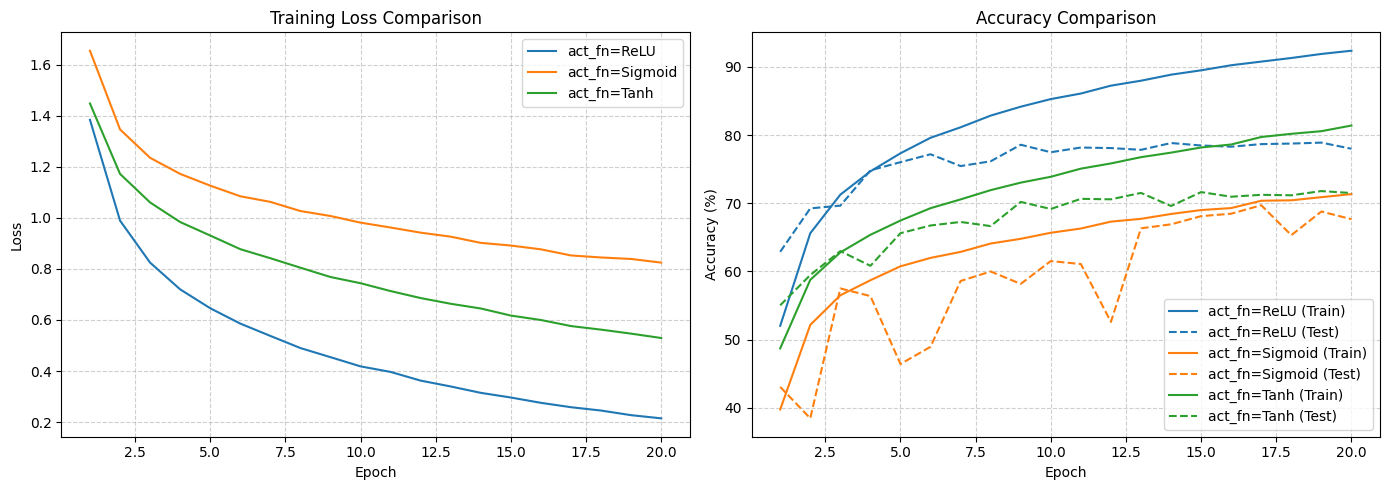

In [85]:
CNN(
    var_name='act_fn', 
    var_values=[nn.ReLU, nn.Sigmoid, nn.Tanh], 
    out_dim=32, 
    weight_decay=1e-4,
    optimizer_type='sgd', 
    lr=0.001, 
    epochs=20
)

5. To optimize your network, you may select one of the following strategies: (8%)
- (a) Try different optimizers using torch.optim

 experiment: CNN_optimizer_type_sgd
 out_dim=32 | act_fn= ReLU | loss_fn=CrossEntropyLoss 
 optimizer_type=sgd | weight_decay= 0.0001
Epoch [01/20] | Loss: 1.3685 | Train Acc: 52.51% | Test Acc: 62.54%
Epoch [02/20] | Loss: 0.9591 | Train Acc: 66.80% | Test Acc: 69.88%
Epoch [03/20] | Loss: 0.8120 | Train Acc: 71.80% | Test Acc: 71.08%
Epoch [04/20] | Loss: 0.7076 | Train Acc: 75.48% | Test Acc: 74.03%
Epoch [05/20] | Loss: 0.6343 | Train Acc: 77.89% | Test Acc: 75.34%
Epoch [06/20] | Loss: 0.5785 | Train Acc: 79.83% | Test Acc: 75.95%
Epoch [07/20] | Loss: 0.5300 | Train Acc: 81.43% | Test Acc: 77.65%
Epoch [08/20] | Loss: 0.4846 | Train Acc: 83.07% | Test Acc: 77.27%
Epoch [09/20] | Loss: 0.4464 | Train Acc: 84.39% | Test Acc: 77.58%
Epoch [10/20] | Loss: 0.4181 | Train Acc: 85.34% | Test Acc: 78.94%
Epoch [11/20] | Loss: 0.3846 | Train Acc: 86.28% | Test Acc: 78.17%
Epoch [12/20] | Loss: 0.3583 | Train Acc: 87.52% | Test Acc: 77.94%
Epoch [13/20] | Loss: 0.3328 | Train Acc: 88.24% |

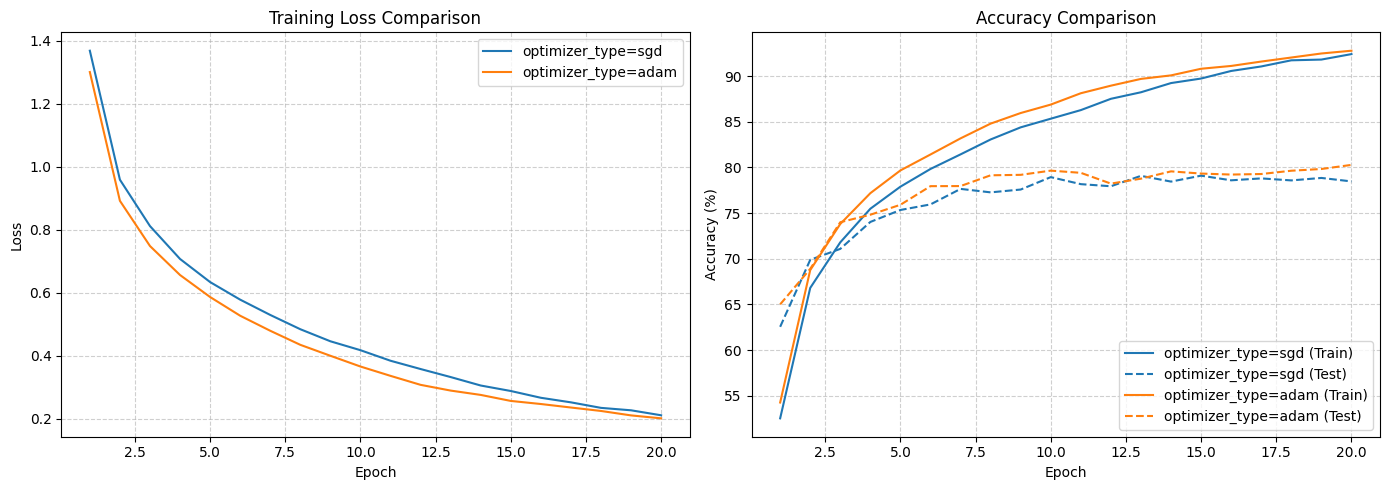

In [86]:
CNN(
    var_name='optimizer_type', 
    var_values=['sgd','adam'], 
    out_dim=32, 
    act_fn=nn.ReLU,
    weight_decay=1e-4,
    lr=0.001, 
    epochs=20
)

6. Reveal the insights of your network, say, visualization of filters, loss landscape, network interpretation. (8%)

 以第一个outdim=32为例

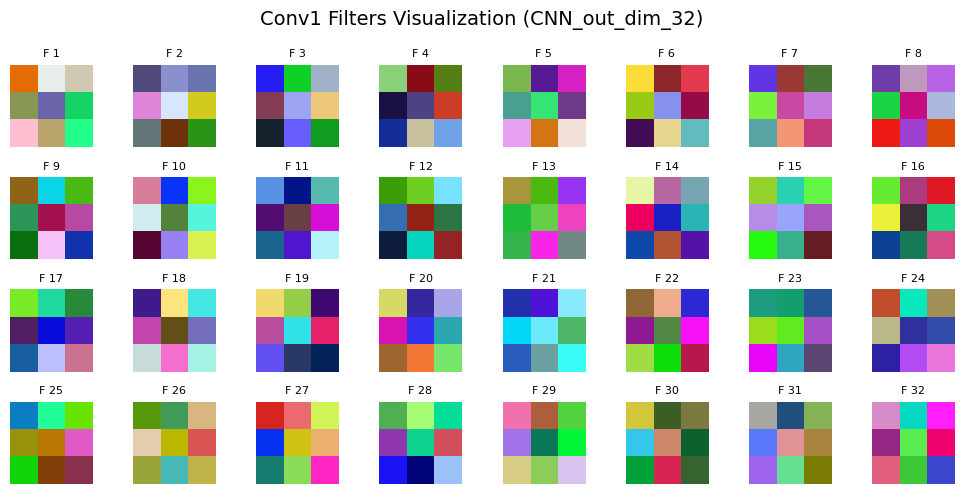

In [87]:
visualize_filters(save_prefix='CNN_out_dim_32')